In [1]:
# Cell 1: Install required packages and import libraries
import subprocess
import sys

# Install required packages (run this cell first)
required_packages = ['tensorflow', 'opencv-python', 'matplotlib', 'seaborn', 
                     'scikit-learn', 'numpy', 'pillow', 'gradio', 'plotly', 
                     'kaleido', 'ipywidgets']

for package in required_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])

print("✅ All packages installed successfully!")

# Now import all libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import MobileNetV2, VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"OpenCV version: {cv2.__version__}")
print("✅ All imports successful!")

✅ All packages installed successfully!
TensorFlow version: 2.21.0
OpenCV version: 4.13.0
✅ All imports successful!


In [2]:
# Cell 2: Define paths and prepare dataset
import shutil
from sklearn.model_selection import train_test_split

# Define paths
BASE_PATH = r"C:\Users\CLEVER PROGRAMMER\Desktop\Malaria_DiseaseDS"
HEALTHY_PATH = os.path.join(BASE_PATH, "Healthy")
INFECTED_PATH = os.path.join(BASE_PATH, "Infected")
MODELS_PATH = os.path.join(BASE_PATH, "Models")
TRAIN_PATH = os.path.join(BASE_PATH, "train")
TEST_PATH = os.path.join(BASE_PATH, "test")

# Create directories
os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(TRAIN_PATH, exist_ok=True)
os.makedirs(TEST_PATH, exist_ok=True)

# Create train/test subfolders
for category in ['Healthy', 'Infected']:
    os.makedirs(os.path.join(TRAIN_PATH, category), exist_ok=True)
    os.makedirs(os.path.join(TEST_PATH, category), exist_ok=True)

# Split dataset (80% train, 20% test)
def split_dataset(source_path, category, train_ratio=0.8):
    images = os.listdir(source_path)
    images = [img for img in images if img.endswith(('.png', '.jpg', '.jpeg'))]
    train_images, test_images = train_test_split(images, train_size=train_ratio, random_state=42)
    
    for img in train_images:
        shutil.copy(os.path.join(source_path, img), os.path.join(TRAIN_PATH, category, img))
    
    for img in test_images:
        shutil.copy(os.path.join(source_path, img), os.path.join(TEST_PATH, category, img))
    
    return len(train_images), len(test_images)

# Split Healthy and Infected
healthy_train, healthy_test = split_dataset(HEALTHY_PATH, 'Healthy')
infected_train, infected_test = split_dataset(INFECTED_PATH, 'Infected')

print(f"📊 Dataset Split Summary:")
print(f"="*50)
print(f"Healthy - Train: {healthy_train} images, Test: {healthy_test} images")
print(f"Infected - Train: {infected_train} images, Test: {infected_test} images")
print(f"Total Train: {healthy_train + infected_train} images")
print(f"Total Test: {healthy_test + infected_test} images")
print(f"\n💾 Models will be saved to: {MODELS_PATH}")

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Load data
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['Healthy', 'Infected']
)

test_generator = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['Healthy', 'Infected'],
    shuffle=False
)

print(f"\n✅ Data loaded successfully!")
print(f"Class indices: {train_generator.class_indices}")

📊 Dataset Split Summary:
Healthy - Train: 800 images, Test: 200 images
Infected - Train: 800 images, Test: 200 images
Total Train: 1600 images
Total Test: 400 images

💾 Models will be saved to: C:\Users\CLEVER PROGRAMMER\Desktop\Malaria_DiseaseDS\Models
Found 1600 images belonging to 2 classes.
Found 400 images belonging to 2 classes.

✅ Data loaded successfully!
Class indices: {'Healthy': 0, 'Infected': 1}


In [7]:
# Cell 3: Build MobileNetV2 Model with Transfer Learning
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization

print("🏗️ Building MobileNetV2 Model...")
print("="*50)

# Load pre-trained MobileNetV2 without top layers
base_model_mobilenet = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model layers
base_model_mobilenet.trainable = False

# Add custom classification head
x = base_model_mobilenet.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

# Create model
mobilenet_model = Model(inputs=base_model_mobilenet.input, outputs=output)

# Compile model
mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC()]
)

# Display model summary
print("\n📋 MobileNetV2 Model Summary:")
mobilenet_model.summary()

print(f"\n✅ MobileNetV2 model built successfully!")
print(f"Total parameters: {mobilenet_model.count_params():,}")
print(f"Trainable parameters: {sum([tf.keras.backend.count_params(w) for w in mobilenet_model.trainable_weights]):,}")

🏗️ Building MobileNetV2 Model...

📋 MobileNetV2 Model Summary:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,620,481 (10.00 MB)

 Trainable params: 361,729 (1.38 MB)

 Non-trainable params: 2,258,752 (8.62 MB)


✅ MobileNetV2 model built successfully!
Total parameters: 2,620,481
Trainable parameters: 361,729


In [8]:
# Cell 4: Train MobileNetV2 Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import time

print("🚀 Training MobileNetV2 Model...")
print("="*50)

# Callbacks for better training
callbacks_mobilenet = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=0.00001,
        verbose=1
    ),
    ModelCheckpoint(
        os.path.join(MODELS_PATH, 'mobilenetv2_best.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Train the model
start_time = time.time()

history_mobilenet = mobilenet_model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator,
    callbacks=callbacks_mobilenet,
    verbose=1
)

training_time = time.time() - start_time

print(f"\n✅ MobileNetV2 training completed in {training_time:.2f} seconds!")

# Save the final model
mobilenet_model.save(os.path.join(MODELS_PATH, 'mobilenetv2_final.keras'))
print(f"💾 MobileNetV2 model saved to: {os.path.join(MODELS_PATH, 'mobilenetv2_final.keras')}")

# Store history for later comparison
mobilenet_history = history_mobilenet

🚀 Training MobileNetV2 Model...
Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7199 - auc_1: 0.8194 - loss: 0.5489 - precision_1: 0.7568 - recall_1: 0.6770
Epoch 1: val_accuracy improved from None to 0.85250, saving model to C:\Users\CLEVER PROGRAMMER\Desktop\Malaria_DiseaseDS\Models\mobilenetv2_best.keras

Epoch 1: finished saving model to C:\Users\CLEVER PROGRAMMER\Desktop\Malaria_DiseaseDS\Models\mobilenetv2_best.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.8087 - auc_1: 0.8940 - loss: 0.4299 - precision_1: 0.8356 - recall_1: 0.7688 - val_accuracy: 0.8525 - val_auc_1: 0.9623 - val_loss: 0.3338 - val_precision_1: 0.9732 - val_recall_1: 0.7250 - learning_rate: 0.0010
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8560 - auc_1: 0.9330 - loss: 0.3440 - precision_1: 0.8575 - recall_1: 0.8344
Epoch 2: val_accuracy improved from 0.85250 to 0.86250, saving model to C:\Users\CLEVER PROGRAMMER\Desktop\Malaria_DiseaseDS\Models\mobilenetv2_best.ker

In [9]:
# Cell 5: Build VGG16 Model with Transfer Learning
print("🏗️ Building VGG16 Model...")
print("="*50)

# Load pre-trained VGG16 without top layers
base_model_vgg16 = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model layers
base_model_vgg16.trainable = False

# Add custom classification head
x = base_model_vgg16.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
output = Dense(1, activation='sigmoid')(x)

# Create model
vgg16_model = Model(inputs=base_model_vgg16.input, outputs=output)

# Compile model
vgg16_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC()]
)

# Display model summary
print("\n📋 VGG16 Model Summary:")
vgg16_model.summary()

print(f"\n✅ VGG16 model built successfully!")
print(f"Total parameters: {vgg16_model.count_params():,}")
print(f"Trainable parameters: {sum([tf.keras.backend.count_params(w) for w in vgg16_model.trainable_weights]):,}")

🏗️ Building VGG16 Model...

📋 VGG16 Model Summary:


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 512)                 │         262,6

 Total params: 15,145,281 (57.77 MB)

 Trainable params: 428,801 (1.64 MB)

 Non-trainable params: 14,716,480 (56.14 MB)


✅ VGG16 model built successfully!
Total parameters: 15,145,281
Trainable parameters: 428,801


In [10]:
# Cell 6: Train VGG16 Model
print("🚀 Training VGG16 Model...")
print("="*50)

# Callbacks for better training
callbacks_vgg16 = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=0.00001,
        verbose=1
    ),
    ModelCheckpoint(
        os.path.join(MODELS_PATH, 'vgg16_best.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Train the model
start_time = time.time()

history_vgg16 = vgg16_model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator,
    callbacks=callbacks_vgg16,
    verbose=1
)

training_time = time.time() - start_time

print(f"\n✅ VGG16 training completed in {training_time:.2f} seconds!")

# Save the final model
vgg16_model.save(os.path.join(MODELS_PATH, 'vgg16_final.keras'))
print(f"💾 VGG16 model saved to: {os.path.join(MODELS_PATH, 'vgg16_final.keras')}")

# Store history for later comparison
vgg16_history = history_vgg16

🚀 Training VGG16 Model...
Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.6621 - auc_2: 0.7273 - loss: 0.6859 - precision_2: 0.6542 - recall_2: 0.6565
Epoch 1: val_accuracy improved from None to 0.50000, saving model to C:\Users\CLEVER PROGRAMMER\Desktop\Malaria_DiseaseDS\Models\vgg16_best.keras

Epoch 1: finished saving model to C:\Users\CLEVER PROGRAMMER\Desktop\Malaria_DiseaseDS\Models\vgg16_best.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 450s 9s/step - accuracy: 0.7362 - auc_2: 0.8102 - loss: 0.5707 - precision_2: 0.7507 - recall_2: 0.7075 - val_accuracy: 0.5000 - val_auc_2: 0.9259 - val_loss: 0.6625 - val_precision_2: 0.5000 - val_recall_2: 1.0000 - learning_rate: 0.0010
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.8042 - auc_2: 0.8824 - loss: 0.4451 - precision_2: 0.8300 - recall_2: 0.7680
Epoch 2: val_accuracy did not improve from 0.50000
50/50 ━━━━━━━━━━━━━━━━━━━━ 459s 9s/step - accuracy: 0.8062 - auc_2: 0.8872 - loss: 0.4326 - precision_2: 0.8249 - recal

In [11]:
# Cell 7: Load best saved models and evaluate on test data
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("📊 Loading and Evaluating Best Models...")
print("="*60)

# Load best models
best_mobilenet = load_model(os.path.join(MODELS_PATH, 'mobilenetv2_best.keras'))
best_vgg16 = load_model(os.path.join(MODELS_PATH, 'vgg16_best.keras'))

# Get predictions
print("Making predictions on test set...")
mobilenet_pred_probs = best_mobilenet.predict(test_generator)
mobilenet_pred = (mobilenet_pred_probs > 0.5).astype(int)

vgg16_pred_probs = best_vgg16.predict(test_generator)
vgg16_pred = (vgg16_pred_probs > 0.5).astype(int)

# Get true labels
y_true = test_generator.classes

# Calculate metrics
def calculate_metrics(y_true, y_pred, y_pred_probs, model_name):
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'AUC-ROC': roc_auc_score(y_true, y_pred_probs)
    }
    return metrics

# Calculate for both models
mobilenet_metrics = calculate_metrics(y_true, mobilenet_pred, mobilenet_pred_probs, 'MobileNetV2')
vgg16_metrics = calculate_metrics(y_true, vgg16_pred, vgg16_pred_probs, 'VGG16')

# Create comparison dataframe
comparison_df = pd.DataFrame([mobilenet_metrics, vgg16_metrics])

print("\n📈 Model Performance Comparison:")
print("="*60)
print(comparison_df.to_string(index=False))
print("="*60)

# Determine best model
best_model_name = comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Model']
best_accuracy = comparison_df['Accuracy'].max()

print(f"\n🏆 BEST MODEL: {best_model_name} with {best_accuracy:.4f} accuracy!")

📊 Loading and Evaluating Best Models...
Making predictions on test set...
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 90s 7s/step

📈 Model Performance Comparison:
      Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
MobileNetV2     0.935   0.953125   0.915  0.933673 0.980175
      VGG16     0.905   0.878505   0.940  0.908213 0.954350

🏆 BEST MODEL: MobileNetV2 with 0.9350 accuracy!


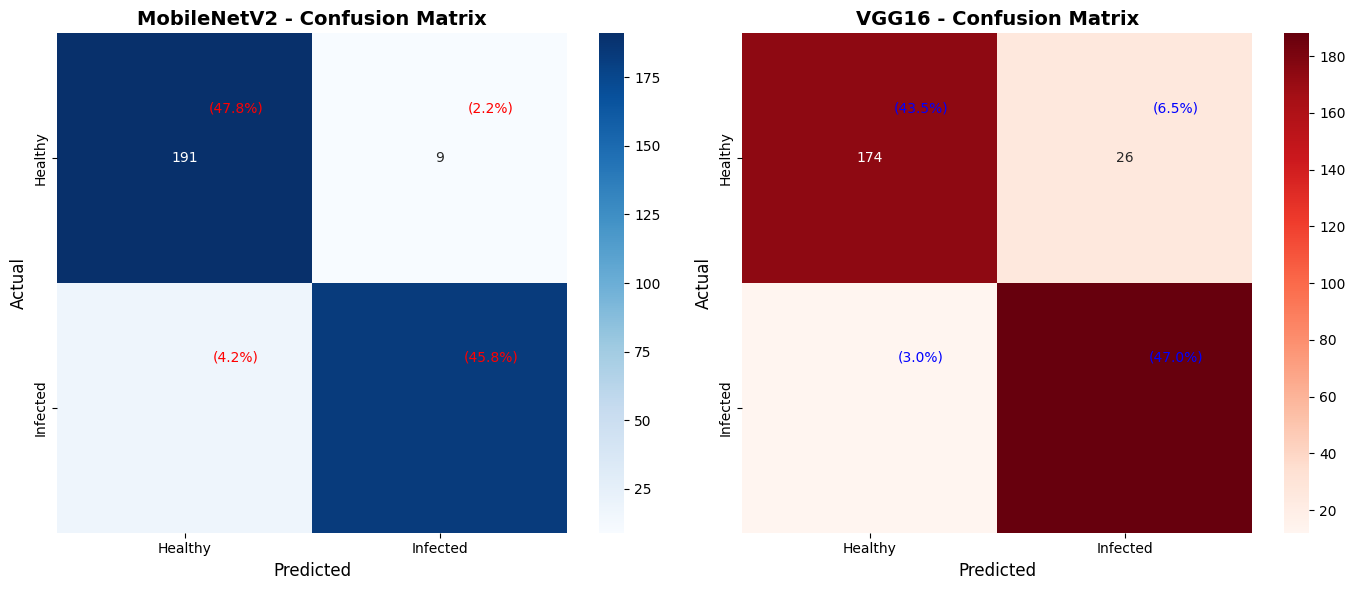


📊 Confusion matrices saved to: C:\Users\CLEVER PROGRAMMER\Desktop\Malaria_DiseaseDS\confusion_matrices_comparison.png

📋 Classification Report - MobileNetV2:
              precision    recall  f1-score   support

     Healthy       0.92      0.95      0.94       200
    Infected       0.95      0.92      0.93       200

    accuracy                           0.94       400
   macro avg       0.94      0.94      0.93       400
weighted avg       0.94      0.94      0.93       400


📋 Classification Report - VGG16:
              precision    recall  f1-score   support

     Healthy       0.94      0.87      0.90       200
    Infected       0.88      0.94      0.91       200

    accuracy                           0.91       400
   macro avg       0.91      0.91      0.90       400
weighted avg       0.91      0.91      0.90       400



In [12]:
# Cell 8: Plot Confusion Matrices for both models
from sklearn.metrics import confusion_matrix
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# MobileNetV2 Confusion Matrix
cm_mobilenet = confusion_matrix(y_true, mobilenet_pred)
sns.heatmap(cm_mobilenet, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Healthy', 'Infected'], 
            yticklabels=['Healthy', 'Infected'],
            ax=axes[0])
axes[0].set_title('MobileNetV2 - Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)

# Add percentage annotations
for i in range(2):
    for j in range(2):
        percentage = cm_mobilenet[i, j] / cm_mobilenet.sum() * 100
        axes[0].text(j+0.7, i+0.3, f'({percentage:.1f}%)', 
                     ha='center', va='center', color='red', fontsize=10)

# VGG16 Confusion Matrix
cm_vgg16 = confusion_matrix(y_true, vgg16_pred)
sns.heatmap(cm_vgg16, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Healthy', 'Infected'], 
            yticklabels=['Healthy', 'Infected'],
            ax=axes[1])
axes[1].set_title('VGG16 - Confusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)

# Add percentage annotations
for i in range(2):
    for j in range(2):
        percentage = cm_vgg16[i, j] / cm_vgg16.sum() * 100
        axes[1].text(j+0.7, i+0.3, f'({percentage:.1f}%)', 
                     ha='center', va='center', color='blue', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'confusion_matrices_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📊 Confusion matrices saved to: {os.path.join(BASE_PATH, 'confusion_matrices_comparison.png')}")

# Print classification reports
print("\n📋 Classification Report - MobileNetV2:")
print("="*50)
print(classification_report(y_true, mobilenet_pred, target_names=['Healthy', 'Infected']))

print("\n📋 Classification Report - VGG16:")
print("="*50)
print(classification_report(y_true, vgg16_pred, target_names=['Healthy', 'Infected']))

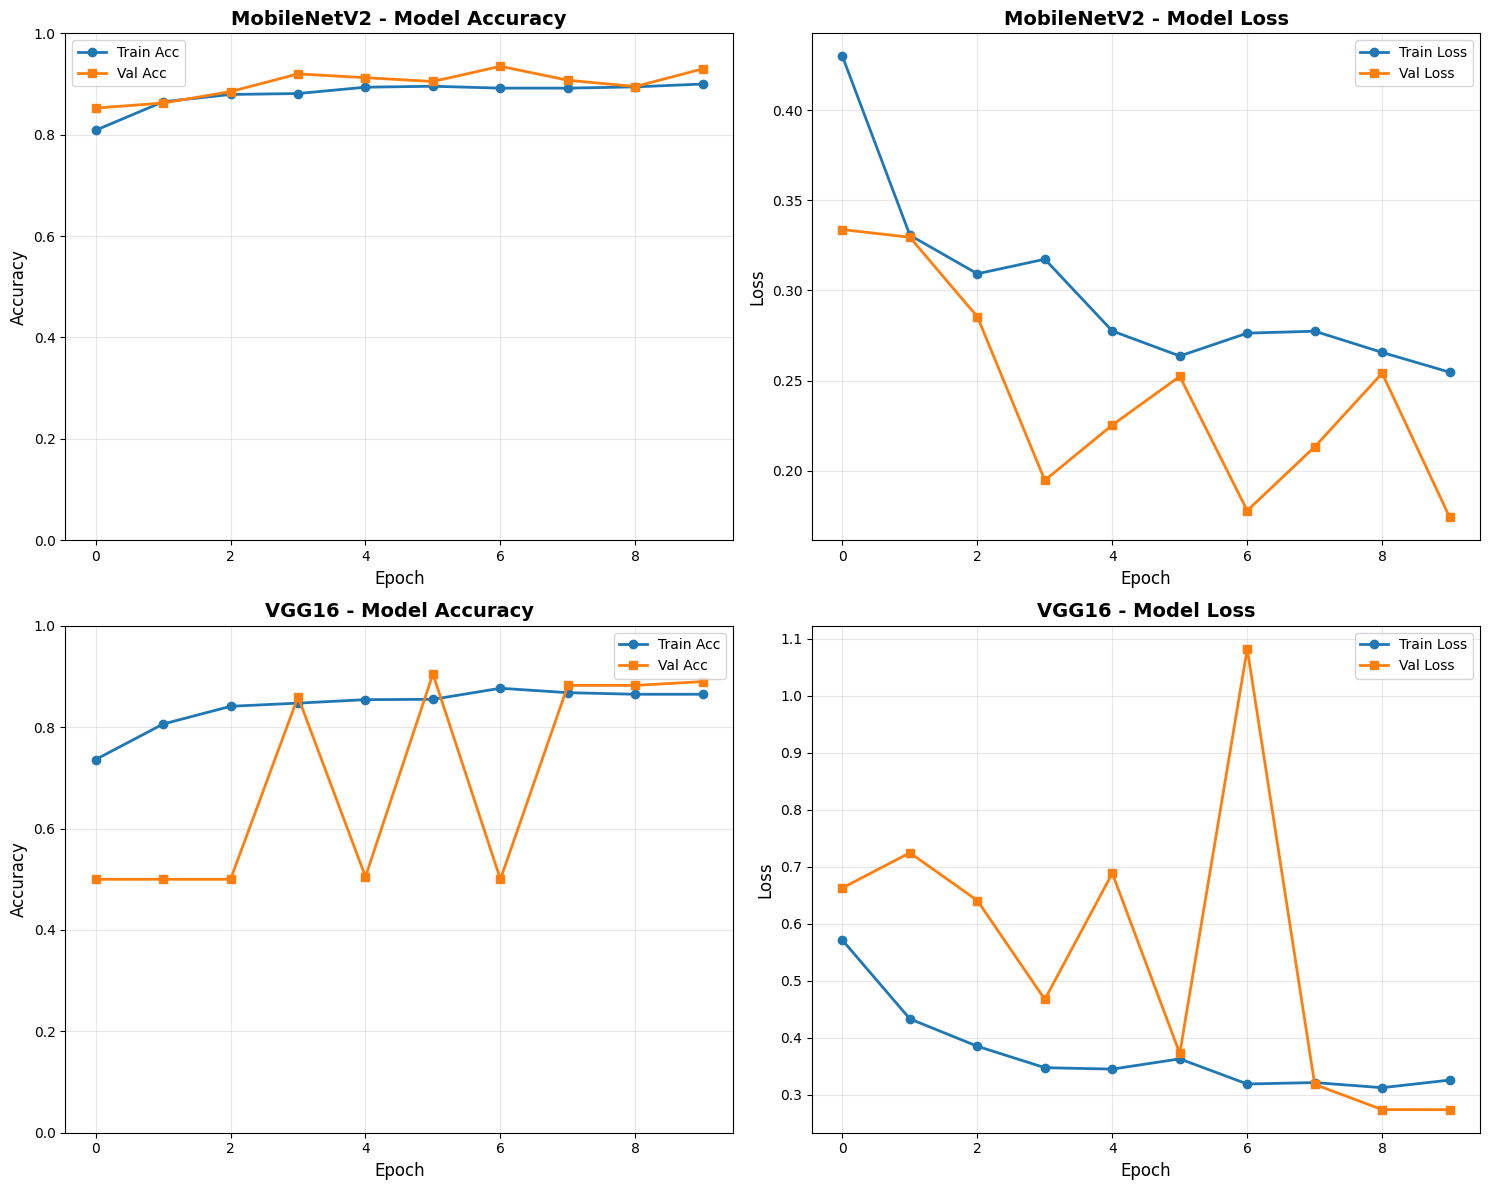

✅ Training curves saved to: C:\Users\CLEVER PROGRAMMER\Desktop\Malaria_DiseaseDS\training_curves_comparison.png


In [13]:
# Cell 9: Plot training accuracy and loss curves for both models
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# MobileNetV2 Accuracy
axes[0, 0].plot(mobilenet_history.history['accuracy'], label='Train Acc', marker='o', linewidth=2)
axes[0, 0].plot(mobilenet_history.history['val_accuracy'], label='Val Acc', marker='s', linewidth=2)
axes[0, 0].set_title('MobileNetV2 - Model Accuracy', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Accuracy', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim([0, 1])

# MobileNetV2 Loss
axes[0, 1].plot(mobilenet_history.history['loss'], label='Train Loss', marker='o', linewidth=2)
axes[0, 1].plot(mobilenet_history.history['val_loss'], label='Val Loss', marker='s', linewidth=2)
axes[0, 1].set_title('MobileNetV2 - Model Loss', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Loss', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# VGG16 Accuracy
axes[1, 0].plot(vgg16_history.history['accuracy'], label='Train Acc', marker='o', linewidth=2)
axes[1, 0].plot(vgg16_history.history['val_accuracy'], label='Val Acc', marker='s', linewidth=2)
axes[1, 0].set_title('VGG16 - Model Accuracy', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Accuracy', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0, 1])

# VGG16 Loss
axes[1, 1].plot(vgg16_history.history['loss'], label='Train Loss', marker='o', linewidth=2)
axes[1, 1].plot(vgg16_history.history['val_loss'], label='Val Loss', marker='s', linewidth=2)
axes[1, 1].set_title('VGG16 - Model Loss', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Loss', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'training_curves_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Training curves saved to: {os.path.join(BASE_PATH, 'training_curves_comparison.png')}")

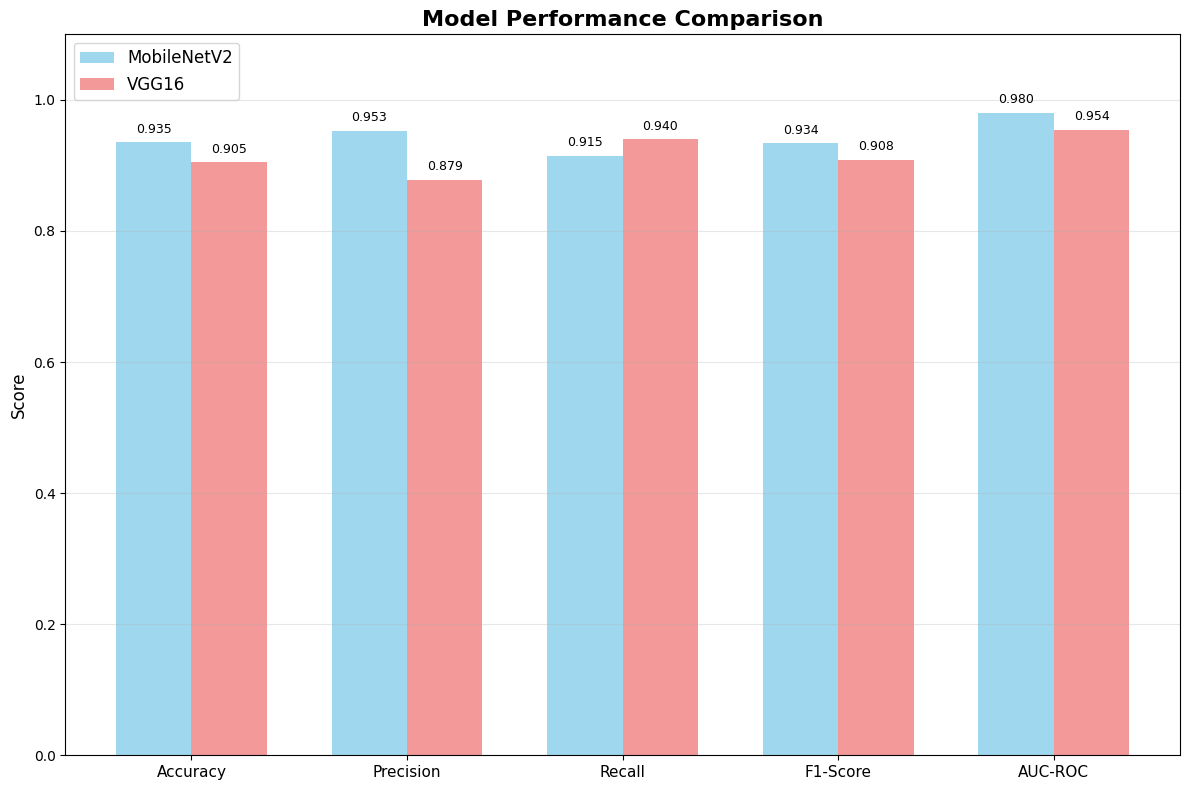


📊 Performance comparison saved!


In [14]:
# Cell 10: Create bar chart comparison of all metrics
fig, ax = plt.subplots(figsize=(12, 8))

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(metrics_to_plot))
width = 0.35

mobilenet_values = [comparison_df[metric].values[0] for metric in metrics_to_plot]
vgg16_values = [comparison_df[metric].values[1] for metric in metrics_to_plot]

bars1 = ax.bar(x - width/2, mobilenet_values, width, label='MobileNetV2', color='skyblue', alpha=0.8)
bars2 = ax.bar(x + width/2, vgg16_values, width, label='VGG16', color='lightcoral', alpha=0.8)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.1])

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'performance_comparison_barchart.png'), dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Performance comparison saved!")

In [ ]:
# CELL 39: Clean Flask Malaria Detection System
import os
import numpy as np
from flask import Flask, request, jsonify, render_template_string
import webbrowser
import threading
import socket
from PIL import Image
import io
import tensorflow as tf
from tensorflow.keras.models import load_model

# Find available port
def find_free_port():
    for port in range(5000, 5010):
        with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
            try:
                s.bind(('127.0.0.1', port))
                return port
            except OSError:
                continue
    return 5000

# Initialize Flask app
app = Flask(__name__)

# Paths
BASE_PATH = r"C:\Users\CLEVER PROGRAMMER\Desktop\Malaria_DiseaseDS"
MODEL_PATH = os.path.join(BASE_PATH, "Models", "mobilenetv2_best.keras")

# Load model silently
model = load_model(MODEL_PATH)

def preprocess_image(image_bytes):
    image = Image.open(io.BytesIO(image_bytes)).convert('RGB').resize((224, 224))
    image_array = np.expand_dims(np.array(image) / 255.0, axis=0)
    return image_array

def predict_image(image_bytes):
    processed = preprocess_image(image_bytes)
    prediction = model.predict(processed, verbose=0)[0][0]
    
    if prediction > 0.5:
        return {
            'result': 'INFECTED',
            'confidence': float(prediction * 100),
            'color': '#ff4444',
            'message': 'Malaria parasites detected in the blood sample',
            'recommendations': [
                'Consult a healthcare provider immediately',
                'Start antimalarial medication as prescribed',
                'Rest and stay hydrated',
                'Monitor symptoms closely',
                'Schedule follow-up test in 7 days'
            ]
        }
    else:
        return {
            'result': 'HEALTHY',
            'confidence': float((1 - prediction) * 100),
            'color': '#00cc66',
            'message': 'No malaria parasites detected',
            'recommendations': [
                'Continue preventive measures',
                'Use mosquito nets',
                'Take preventive medication if in high-risk area',
                'Regular check-ups recommended',
                'Maintain good hygiene'
            ]
        }

HTML_TEMPLATE = '''
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Malaria Detection System</title>
    <style>
        * { margin: 0; padding: 0; box-sizing: border-box; }
        body {
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            min-height: 100vh;
            padding: 20px;
        }
        .container { max-width: 900px; margin: 0 auto; }
        .header {
            background: white;
            border-radius: 20px;
            padding: 25px;
            margin-bottom: 25px;
            text-align: center;
            box-shadow: 0 10px 30px rgba(0,0,0,0.1);
        }
        .header h1 { color: #333; font-size: 1.8em; margin-bottom: 8px; }
        .header p { color: #666; font-size: 0.9em; }
        .card {
            background: white;
            border-radius: 20px;
            padding: 25px;
            margin-bottom: 25px;
            box-shadow: 0 10px 30px rgba(0,0,0,0.1);
        }
        .upload-area {
            border: 2px dashed #667eea;
            border-radius: 15px;
            padding: 40px;
            text-align: center;
            cursor: pointer;
            transition: all 0.3s;
            background: #fafafa;
        }
        .upload-area:hover { background: #f0f0ff; border-color: #764ba2; }
        .preview-image {
            max-width: 100%;
            max-height: 300px;
            border-radius: 10px;
            margin-top: 15px;
            display: none;
        }
        .button-group { display: flex; gap: 15px; margin-top: 20px; }
        button {
            flex: 1;
            padding: 12px;
            border: none;
            border-radius: 10px;
            font-size: 16px;
            font-weight: 600;
            cursor: pointer;
            color: white;
            transition: all 0.3s;
        }
        .btn-detect { background: linear-gradient(135deg, #667eea, #764ba2); }
        .btn-clear { background: #ff6b6b; }
        button:hover { transform: translateY(-2px); box-shadow: 0 5px 15px rgba(0,0,0,0.2); }
        .loading {
            display: none;
            text-align: center;
            padding: 20px;
        }
        .spinner {
            border: 4px solid #f3f3f3;
            border-top: 4px solid #667eea;
            border-radius: 50%;
            width: 50px;
            height: 50px;
            animation: spin 1s linear infinite;
            margin: 0 auto;
        }
        @keyframes spin {
            0% { transform: rotate(0deg); }
            100% { transform: rotate(360deg); }
        }
        .confidence-circle {
            width: 150px;
            height: 150px;
            border-radius: 50%;
            margin: 20px auto;
            display: flex;
            align-items: center;
            justify-content: center;
        }
        .confidence-inner {
            width: 120px;
            height: 120px;
            border-radius: 50%;
            background: white;
            display: flex;
            align-items: center;
            justify-content: center;
            flex-direction: column;
            box-shadow: 0 2px 10px rgba(0,0,0,0.1);
        }
        .confidence-value { font-size: 28px; font-weight: bold; }
        .recommendations {
            text-align: left;
            margin-top: 20px;
            padding: 15px;
            background: #f8f9fa;
            border-radius: 10px;
        }
        .recommendations ul { margin-left: 20px; margin-top: 10px; }
        .recommendations li { margin: 8px 0; }
        .notification {
            position: fixed;
            top: 20px;
            right: 20px;
            padding: 12px 20px;
            border-radius: 10px;
            color: white;
            z-index: 1000;
            animation: slideIn 0.3s ease;
        }
        @keyframes slideIn {
            from { transform: translateX(100%); opacity: 0; }
            to { transform: translateX(0); opacity: 1; }
        }
        .footer { text-align: center; color: white; margin-top: 20px; font-size: 0.8em; }
        @media (max-width: 768px) {
            .header h1 { font-size: 1.3em; }
            .button-group { flex-direction: column; }
        }
    </style>
</head>
<body>
    <div class="container">
        <div class="header">
            <h1>AI-Powered Malaria Detection System</h1>
            <p>JINKA UNIVERSITY - Department of Computer Science</p>
        </div>
        
        <div class="card">
            <div class="upload-area" id="uploadArea">
                <div style="font-size: 48px;">📷</div>
                <p>Click or drag & drop to upload image</p>
                <p style="font-size: 12px; color: #999;">Supports: JPG, PNG, JPEG</p>
            </div>
            <input type="file" id="imageInput" accept="image/*" style="display: none;">
            <img id="preview" class="preview-image">
            <div class="button-group">
                <button class="btn-detect" id="detectBtn">Detect Malaria</button>
                <button class="btn-clear" id="clearBtn">Clear</button>
            </div>
        </div>
        
        <div id="loading" class="loading">
            <div class="spinner"></div>
            <p style="margin-top: 10px;">Analyzing blood sample...</p>
        </div>
        
        <div id="resultArea" style="display: none;">
            <div class="card">
                <div id="resultContent"></div>
            </div>
        </div>
        
        <div class="footer">
            <p>JINKA UNIVERSITY | 3rd Year G1 Students | 2026</p>
        </div>
    </div>
    
    <script>
        const uploadArea = document.getElementById('uploadArea');
        const imageInput = document.getElementById('imageInput');
        const preview = document.getElementById('preview');
        const detectBtn = document.getElementById('detectBtn');
        const clearBtn = document.getElementById('clearBtn');
        const loading = document.getElementById('loading');
        const resultArea = document.getElementById('resultArea');
        let currentImage = null;
        
        uploadArea.addEventListener('click', () => imageInput.click());
        uploadArea.addEventListener('dragover', (e) => { e.preventDefault(); uploadArea.style.background = '#f0f0ff'; });
        uploadArea.addEventListener('dragleave', () => { uploadArea.style.background = '#fafafa'; });
        uploadArea.addEventListener('drop', (e) => {
            e.preventDefault();
            uploadArea.style.background = '#fafafa';
            const file = e.dataTransfer.files[0];
            if (file && file.type.startsWith('image/')) handleImage(file);
        });
        imageInput.addEventListener('change', (e) => { if (e.target.files[0]) handleImage(e.target.files[0]); });
        
        function handleImage(file) {
            const reader = new FileReader();
            reader.onload = (e) => {
                preview.src = e.target.result;
                preview.style.display = 'block';
                currentImage = file;
                uploadArea.style.display = 'none';
            };
            reader.readAsDataURL(file);
        }
        
        function showNotification(message, isError = false) {
            const notification = document.createElement('div');
            notification.className = 'notification';
            notification.style.background = isError ? '#ff4444' : '#00cc66';
            notification.innerHTML = message;
            document.body.appendChild(notification);
            setTimeout(() => notification.remove(), 3000);
        }
        
        function clearAll() {
            currentImage = null;
            preview.src = '';
            preview.style.display = 'none';
            uploadArea.style.display = 'block';
            imageInput.value = '';
            resultArea.style.display = 'none';
            showNotification('Cleared!');
        }
        
        clearBtn.addEventListener('click', clearAll);
        
        detectBtn.addEventListener('click', async () => {
            if (!currentImage) {
                showNotification('Please upload an image first', true);
                return;
            }
            
            loading.style.display = 'block';
            resultArea.style.display = 'none';
            
            const formData = new FormData();
            formData.append('image', currentImage);
            
            try {
                const response = await fetch('/detect', { method: 'POST', body: formData });
                const data = await response.json();
                
                if (data.error) {
                    showNotification(data.error, true);
                } else {
                    document.getElementById('resultContent').innerHTML = `
                        <div style="text-align: center;">
                            <h2 style="color: ${data.color};">${data.result}</h2>
                            <div class="confidence-circle" style="background: conic-gradient(from 0deg, ${data.color} 0%, ${data.color} ${data.confidence}%, #e0e0e0 ${data.confidence}%);">
                                <div class="confidence-inner">
                                    <div class="confidence-value" style="color: ${data.color};">${data.confidence.toFixed(1)}%</div>
                                    <div style="font-size: 12px;">confidence</div>
                                </div>
                            </div>
                            <p style="margin: 20px 0;">${data.message}</p>
                            <div class="recommendations">
                                <strong>Recommendations:</strong>
                                <ul>${data.recommendations.map(rec => `<li>${rec}</li>`).join('')}</ul>
                            </div>
                        </div>
                    `;
                    resultArea.style.display = 'block';
                    showNotification('Detection complete!');
                }
            } catch (error) {
                showNotification('Error: ' + error.message, true);
            } finally {
                loading.style.display = 'none';
            }
        });
    </script>
</body>
</html>
'''

@app.route('/')
def index():
    return render_template_string(HTML_TEMPLATE)

@app.route('/detect', methods=['POST'])
def detect():
    try:
        if 'image' not in request.files:
            return jsonify({'error': 'No image uploaded'}), 400
        
        image_file = request.files['image']
        diagnosis = predict_image(image_file.read())
        return jsonify(diagnosis)
    except Exception as e:
        return jsonify({'error': str(e)}), 500

def open_browser():
    webbrowser.open('http://127.0.0.1:5000')

if __name__ == '__main__':
    port = find_free_port()
    print(f"\nMalaria Detection System Ready at http://127.0.0.1:{port}\n")
    threading.Timer(1.5, open_browser).start()
    app.run(host='127.0.0.1', port=port, debug=False)